# Assignment 1: Wrangling and EDA
### Foundations of Machine Learning

**Q1.** This question provides some practice cleaning variables which have common problems.
1. Numeric variable: For `airbnb_NYC.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. Categorical variable: For the Minnesota police use of for data, `mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? For the remaining missing values, replace the `np.nan/None` values with the label `Missing`.
3. Dummy variable: For `metabric.csv`, convert the `Overall Survival Status` variable into a dummy/binary variable, taking the value 0 if the patient is deceased and 1 if they are living.
4. Missing values: For `airbnb_NYC.csv`, determine how many missing values of `Review Scores Rating` there are. Create a new variable, in which you impute the median score for non-missing observations to the missing ones. Why might this bias or otherwise negatively impact your results?

In [1]:
import pandas as pd
import numpy as np

In [2]:
airbnb = pd.read_csv("airbnb_NYC.csv", encoding="latin1")

airbnb["Price_clean"] = (
    airbnb["Price"]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .replace("nan", np.nan)
    .astype(float)
)

In [3]:
mn = pd.read_csv("mn_police_use_of_force.csv", encoding="latin1")

mn["subject_injury_clean"] = mn["subject_injury"].map(
    lambda x: "Yes" if str(x).strip().lower() == "yes"
    else ("No" if str(x).strip().lower() == "no" else np.nan)
)

pd.crosstab(mn["subject_injury_clean"], mn["force_type"], dropna=False)

mn["subject_injury_clean"] = mn["subject_injury_clean"].fillna("Missing")

In [4]:
metabric = pd.read_csv("metabric.csv")

metabric["Overall_Survival_Dummy"] = metabric["Overall Survival Status"].map(
    {"0:LIVING": 1, "1:DECEASED": 0}
)

In [5]:
median_score = airbnb["Review Scores Rating"].median()

airbnb["Review_Scores_Imputed"] = airbnb["Review Scores Rating"].fillna(median_score)

In [6]:

print("Airbnb Price")
print(airbnb[["Price", "Price_clean"]].head())
print("\nMissing Price_clean:", airbnb["Price_clean"].isna().sum())

print("MN Police: Subject Injury")
print(mn["subject_injury_clean"].value_counts(dropna=False))
print("\nCrosstab (Injury x Force Type):")
print(pd.crosstab(mn["subject_injury_clean"], mn["force_type"]))

print("METABRIC Survival Dummy")
print(metabric[["Overall Survival Status", "Overall_Survival_Dummy"]].value_counts())

print(" Airbnb Review Scores")
print("Missing before:", airbnb["Review Scores Rating"].isna().sum())
print("Median used:", airbnb["Review Scores Rating"].median())
print("Missing after:", airbnb["Review_Scores_Imputed"].isna().sum())

Airbnb Price
  Price  Price_clean
0   145        145.0
1    37         37.0
2    28         28.0
3   199        199.0
4   549        549.0

Missing Price_clean: 0
MN Police: Subject Injury
subject_injury_clean
Missing    9848
Yes        1631
No         1446
Name: count, dtype: int64

Crosstab (Injury x Force Type):
force_type            Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury_clean                                                    
Missing                   2          7051               1421        0   
No                        0          1093                131        2   
Yes                       2          1286                 41        0   

force_type            Gun Point Display  Improvised Weapon  Less Lethal  \
subject_injury_clean                                                      
Missing                              27                 74           87   
No                                   33                 34            0   
Yes              

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks.

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work. What does work?
2. Drop any columns that do not contain data.
3. What is an observation? Carefully justify your answer, and explain how it affects your choices in cleaning and analyzing the data.
4. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
5. Clean the Age variable and make a histogram of the ages of the victims.
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
7. Clean the `Fatal Y/N` variable so it only takes three values: Y, N, and Unknown.
8. Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Thoughts?

Year range (raw cleaned): 1800.0 to 2026.0


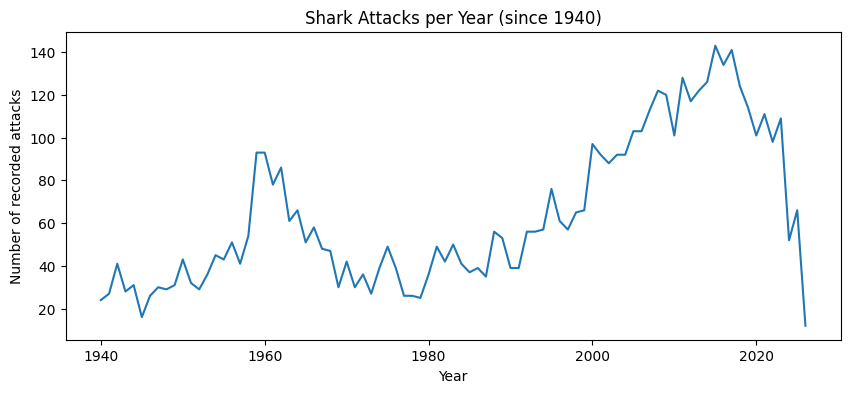

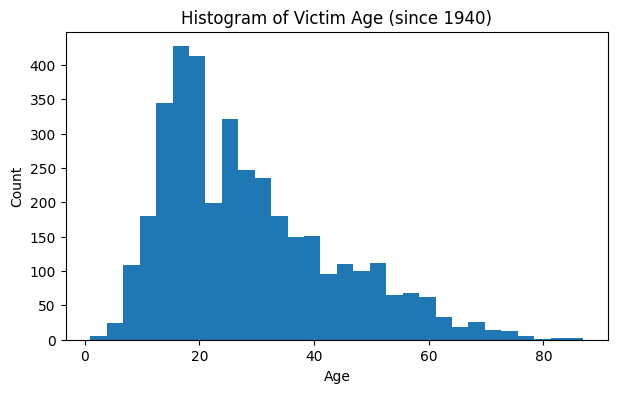


Type proportions:
 Type_clean
Unprovoked    0.745034
Unknown       0.160527
Provoked      0.094438
Name: proportion, dtype: float64

Proportion unprovoked: 0.7450343084145901

Fatal proportions:
 Fatal_clean
N          0.766883
Y          0.150054
Unknown    0.083062
Name: proportion, dtype: float64
Fatality rate by Type (Y share, Unknown removed):
            fatal_rate     n
Type_clean                  
Provoked      0.025292   514
Unknown       0.253061   490
Unprovoked    0.170349  4074


In [7]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

#1

df = pd.read_csv("GSAF5(Sheet1-GSAF).csv", encoding="latin1", low_memory=False)

#2 Drop columns 
df = df.dropna(axis=1, how="all").copy()

def clean_year(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    m = re.search(r"(18|19|20)\d{2}", s)  # grab a 4-digit year if present
    return float(m.group(0)) if m else np.nan

def clean_age(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()

    if s in ["", "nan", "unknown", "unidentified", "?", " "]:
        return np.nan

    m = re.search(r"\d{1,3}", s)
    if not m:
        return np.nan
    age = float(m.group(0))
    return age if 0 < age < 120 else np.nan

def clean_type(x):
    if pd.isna(x):
        return "Unknown"
    s = str(x).strip().lower()
    if "unprov" in s:
        return "Unprovoked"
    if "provok" in s:
        return "Provoked"
    return "Unknown"

def clean_fatal(x):
    if pd.isna(x):
        return "Unknown"
    s = str(x).strip().upper()
    if s.startswith("Y"):
        return "Y"
    if s.startswith("N"):
        return "N"
    return "Unknown"

# 4
df["Year_clean"] = df["Year"].apply(clean_year)

print("Year range (raw cleaned):", df["Year_clean"].min(), "to", df["Year_clean"].max())

df_1940 = df[df["Year_clean"] >= 1940].copy()

year_counts = (
    df_1940["Year_clean"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,4))
plt.plot(year_counts.index, year_counts.values)
plt.title("Shark Attacks per Year (since 1940)")
plt.xlabel("Year")
plt.ylabel("Number of recorded attacks")
plt.show()

# 5) Clean Age + histogram
df_1940["Age_clean"] = df_1940["Age"].apply(clean_age)

plt.figure(figsize=(7,4))
plt.hist(df_1940["Age_clean"].dropna(), bins=30)
plt.title("Histogram of Victim Age (since 1940)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# 6) Clean Type + proportion unprovoked
df_1940["Type_clean"] = df_1940["Type"].apply(clean_type)
type_props = df_1940["Type_clean"].value_counts(normalize=True)
print("\nType proportions:\n", type_props)
print("\nProportion unprovoked:", type_props.get("Unprovoked", 0.0))

# 7) Y/N
df_1940["Fatal_clean"] = df_1940["Fatal Y/N"].apply(clean_fatal)
print("\nFatal proportions:\n", df_1940["Fatal_clean"].value_counts(normalize=True))

# 8) Fatality by Type (provoked vs unprovoked)
tmp = df_1940[df_1940["Fatal_clean"].isin(["Y","N"])].copy()
tmp["Fatal_binary"] = (tmp["Fatal_clean"] == "Y").astype(int)

fatal_rates = tmp.groupby("Type_clean")["Fatal_binary"].mean().sort_values(ascending=False)
counts_by_type = tmp.groupby("Type_clean")["Fatal_binary"].size()

print("Fatality rate by Type (Y share, Unknown removed):")
print(pd.DataFrame({"fatal_rate": fatal_rates, "n": counts_by_type}))


**Q3.** Open the "tidy_data.pdf" document available in `https://github.com/ds4e/wrangling`, which is a paper called *Tidy Data* by Hadley Wickham.

  1. Read the abstract. What is this paper about?
  2. Read the introduction. What is the "tidy data standard" intended to accomplish?
  3. Read the intro to section 2. What does this sentence mean: "Like families, tidy datasets are all alike but every messy dataset is messy in its own way." What does this sentence mean: "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."
  4. Read Section 2.2. How does Wickham define values, variables, and observations?
  5. How is "Tidy Data" defined in section 2.3?
  6. Read the intro to Section 3 and Section 3.1. What are the 5 most common problems with messy datasets? Why are the data in Table 4 messy? What is "melting" a dataset?
  7. Why, specifically, is table 11 messy but table 12 tidy and "molten"?

1) The paper is about data tidying data, a part of data cleaning that shows how datasets should , a specific part of data cleaning that focuses on how datasets should be structured to make analysis easier. Wickham argues that tidy data, where variables, observations, and tables follow a consistent structure makes data easier to manipulate, visualize, and model.

2) The tidy data standard is intended to provide a consistent, general-purpose structure for datasets so analysts do not need to repeatedly reinvent ways to clean and reorganize data. Its goal is to reduce time spent on data wrangling and allow analysts to focus on the substantive problem rather than logistics.

3) “Like families, tidy datasets are all alike but every messy dataset is messy in its own way.” This means that tidy datasets follow the same predictable structure, while messy datasets can be disorganized in many different, inconsistent ways, making them harder to work with.“For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general. This means that while we can often intuitively identify variables and observations in a specific dataset, there is no single universal definition that works in all contexts because the meaning depends on the analysis and research question.

4) Values are the individual entries in a dataset (numbers or strings). Variables are collections of values that measure the same underlying attribute across units. Observations are collections of values measured on the same unit across variables.

5) Data is tidy if, Each variable forms a column, Each observation forms a row, Each type of observational unit forms its own table

6) Column headers are values, not variable names. Multiple variables are stored in one column. Variables are stored in both rows and columns. Multiple types of observational units are stored in one table. A single observational unit is stored across multiple tablesTable 4 is messy because the column headers represent values of a variable (income levels) rather than variable names. This makes it difficult to treat income as a variable in analysis. Melting is the process of converting columns into rows so that values stored in column headers become values of a variable, producing a long-format dataset.

7) Table 11 is messy because, variables are stored across both rows and columns. Column names represent days rather than variables. A variable name (tmin, tmax) is stored as data in a column Table 12 is tidy and molten because, each row represents a single observation (one day). Each variable has its own column. The dataset has been melted so values are explicitly stored in rows rather than spread across columns

**Q4.** This question looks at financial transfers from international actors to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? 

For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
5. What are the top 15 institutions in terms of the total amount of money they receive? Make a histogram of the total amount received by all institutions. 
6. Which giftors provide the most money, in total? 

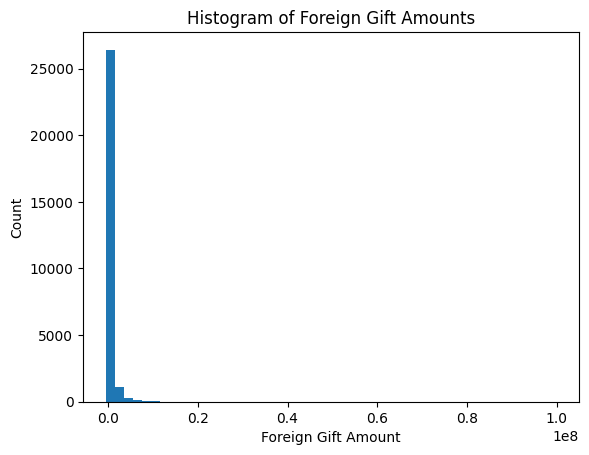

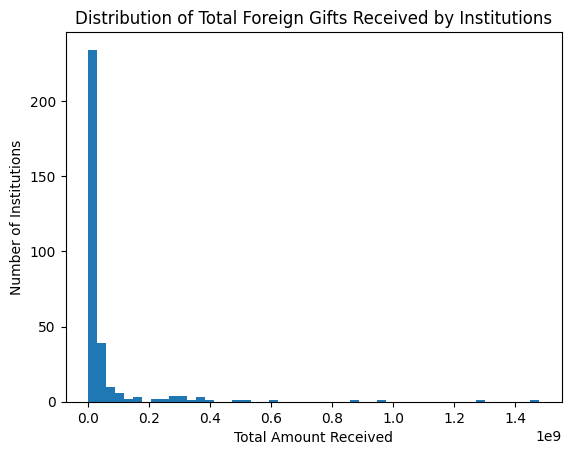

Giftor Name
Qatar Foundation                       1.166504e+09
Qatar Foundation/Qatar National Res    7.961970e+08
Qatar Foundation for Education         3.739452e+08
Anonymous                              3.387936e+08
Saudi Arabian Cultural Mission         2.752215e+08
HCL                                    1.900000e+08
Church of Jesus Christ of LDS          1.852037e+08
Emirates Institute for Advanced Sc     1.706412e+08
QIC                                    1.483555e+08
Anonymous #9                           9.633500e+07
Qatar National Research Fund           7.902170e+07
Government of Saudi Arabia             7.519243e+07
Contracting Party                      6.999698e+07
CMKL University                        6.770000e+07
Royal Embassy of Saudi Arabia          6.706249e+07
Name: Foreign Gift Amount_clean, dtype: float64

In [8]:
#1 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ForeignGifts_edu.csv", encoding="latin1")
df.head()

#2 
df["Foreign Gift Amount_clean"] = (
    df["Foreign Gift Amount"]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .replace("nan", np.nan)
    .astype(float)
)

plt.hist(df["Foreign Gift Amount_clean"].dropna(), bins=50)
plt.xlabel("Foreign Gift Amount")
plt.ylabel("Count")
plt.title("Histogram of Foreign Gift Amounts")
plt.show()

df["Foreign Gift Amount_clean"].describe()

#3
gift_type_counts = df["Gift Type"].value_counts()
gift_type_props = df["Gift Type"].value_counts(normalize=True)

gift_type_counts
gift_type_props


#4
top_countries_count = (
    df.groupby("Country of Giftor")
    .size()
    .sort_values(ascending=False)
    .head(15)
)

top_countries_count

top_countries_amount = (
    df.groupby("Country of Giftor")["Foreign Gift Amount_clean"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_countries_amount


#5
top_institutions = (
    df.groupby("Institution Name")["Foreign Gift Amount_clean"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_institutions

institution_totals = (
    df.groupby("Institution Name")["Foreign Gift Amount_clean"]
    .sum()
)

plt.hist(institution_totals.dropna(), bins=50)
plt.xlabel("Total Amount Received")
plt.ylabel("Number of Institutions")
plt.title("Distribution of Total Foreign Gifts Received by Institutions")
plt.show()

#6
top_giftors = (
    df.groupby("Giftor Name")["Foreign Gift Amount_clean"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_giftors






**Q5.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `college_completion.csv` dataset from the US Department of Education. The "relevant" variables for this question are:
  - `level` - Level of institution (4-year, 2-year)
  - `aid_value` - The average amount of student aid going to undergraduate recipients
  - `control` - Public, Private not-for-profit, Private for-profit
  - `grad_100_value` - percentage of first-time, full-time, degree-seeking undergraduates who complete a degree or certificate program within 100 percent of expected time (bachelor's-seeking group at 4-year institutions)

1. Load the `college_completion.csv` data with Pandas.
2. How many observations and variables are in the data? Use `.head()` to examine the first few rows of data.
3. Cross tabulate `control` and `level`. Describe the patterns you see in words.
4. For `grad_100_value`, create a kernel density plot and describe table. Now condition on `control`, and produce a kernel density plot and describe tables for each type of institutional control. Which type of institution appear to have the most favorable graduation rates?
5. Make a scatterplot of `grad_100_value` by `aid_value`, and compute the covariance and correlation between the two variables. Describe what you see. Now make the same plot and statistics, but conditioning on `control`. Describe what you see. For which kinds of institutions does aid seem to vary positively with graduation rates?

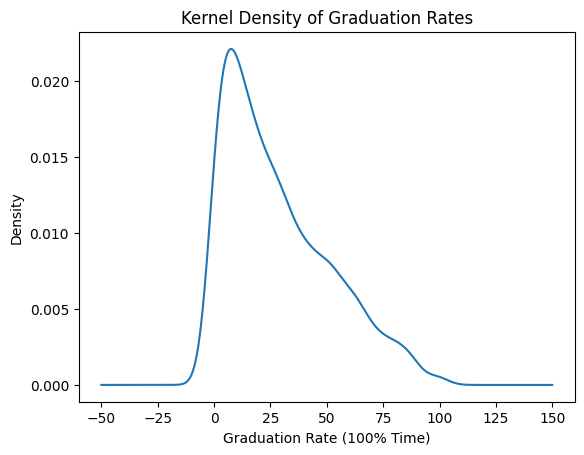

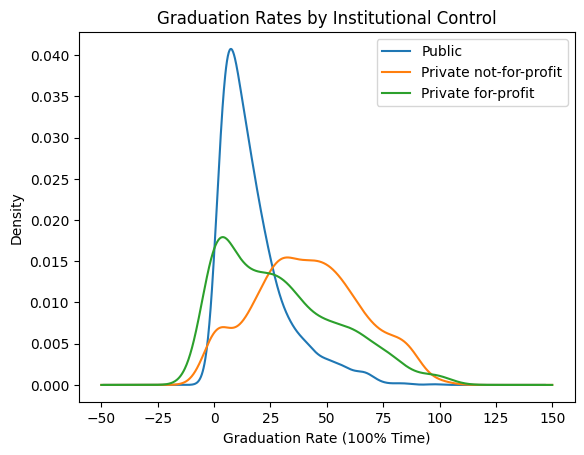

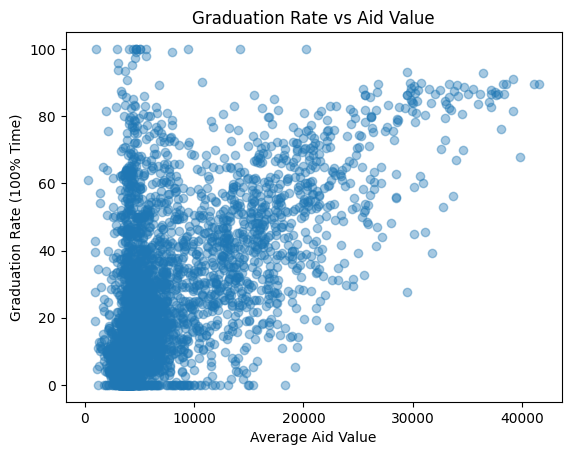

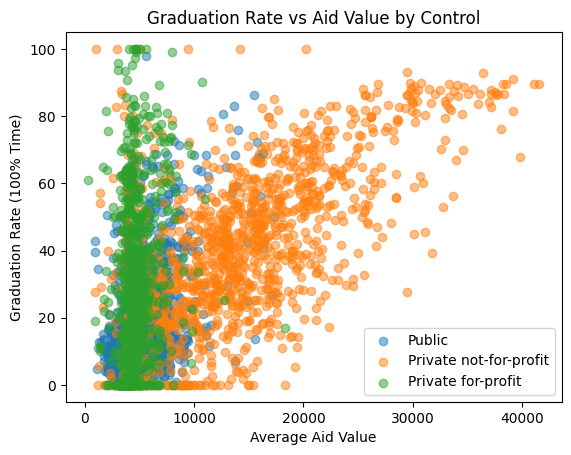

aid_value  grad_100_value
control                                                         
Private for-profit     aid_value        1.000000        0.188363
                       grad_100_value   0.188363        1.000000
Private not-for-profit aid_value        1.000000        0.601591
                       grad_100_value   0.601591        1.000000
Public                 aid_value        1.000000        0.482481
                       grad_100_value   0.482481        1.000000

In [9]:
#1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("college_completion.csv")
df.head()


#2
df.shape
df.head()

#3
pd.crosstab(df["control"], df["level"])

#4
df["grad_100_value"].plot(kind="kde")
plt.xlabel("Graduation Rate (100% Time)")
plt.title("Kernel Density of Graduation Rates")
plt.show()

df["grad_100_value"].describe()

for c in df["control"].unique():
    df[df["control"] == c]["grad_100_value"].plot(kind="kde", label=c)

plt.legend()
plt.xlabel("Graduation Rate (100% Time)")
plt.title("Graduation Rates by Institutional Control")
plt.show()
df.groupby("control")["grad_100_value"].describe()

#5
plt.scatter(df["aid_value"], df["grad_100_value"], alpha=0.4)
plt.xlabel("Average Aid Value")
plt.ylabel("Graduation Rate (100% Time)")
plt.title("Graduation Rate vs Aid Value")
plt.show()

cov = df[["aid_value", "grad_100_value"]].cov().iloc[0,1]
corr = df[["aid_value", "grad_100_value"]].corr().iloc[0,1]

cov, corr
for c in df["control"].unique():
    sub = df[df["control"] == c]
    
    plt.scatter(sub["aid_value"], sub["grad_100_value"], alpha=0.5, label=c)
    
plt.xlabel("Average Aid Value")
plt.ylabel("Graduation Rate (100% Time)")
plt.legend()
plt.title("Graduation Rate vs Aid Value by Control")
plt.show()
df.groupby("control")[["aid_value", "grad_100_value"]].corr()


**Q6.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

We're going to look at **linear transformations** of $X$, $Y = a + bX$. So we take each value of $X$, $x_i$, and transform it as $y_i = a + b x_i$. 

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $ \text{cov}(X,X) = s^2$.
3. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
4. Show that $\text{cov}(a+bX,a+bY) = b^2 \text{cov}(X,Y) $. Notice, this also means that $\text{cov}(bX, bX) = b^2 s^2$.
5. Suppose $b>0$ and let the median of $X$ be $\text{med}(X)$. Is it true that the median of $a+bX$ is equal to $a + b \times \text{med}(X)$? Is the IQR of $a + bX$ equal to $a + b \times \text{IQR}(X)$?
6. Show by example that the means of $X^2$ and $\sqrt{X}$ are generally not $(m(X))^2$ and $\sqrt{m(X)}$. So, the results we derived above really depend on the linearity of the transformation $Y = a + bX$, and transformations like $Y = X^2$ or $Y = \sqrt{X}$ will not behave in a similar way.

![Q1-3](1000013035.jpg)
![Q4-6](1000013036.jpg)

**Q7.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `ames_prices.csv` dataset. The "relevant" variables for this question are:
  - `price` - Sale price value of the house
  - `Bldg.Type` - Building type of the house (single family home, end-of-unit townhome, duplex, interior townhome, two-family conversion)

1. Load the `college_completion.csv` data with Pandas.
2. Make a kernel density plot of price and compute a describe table. Now, make a kernel density plot of price conditional on building type, and use `.groupby()` to make a describe type for each type of building. Which building types are the most expensive, on average? Which have the highest variance in transaction prices?
3. Make an ECDF plot of price, and compute the sample minimum, .25 quantile, median, .75 quantile, and sample maximum (i.e. a 5-number summary).
4. Make a boxplot of price. Are there outliers? Make a boxplot of price conditional on building type. What patterns do you see?
5. Make a dummy variable indicating that an observation is an outlier.
6. Winsorize the price variable, and compute a new kernel density plot and describe table. How do the results change?

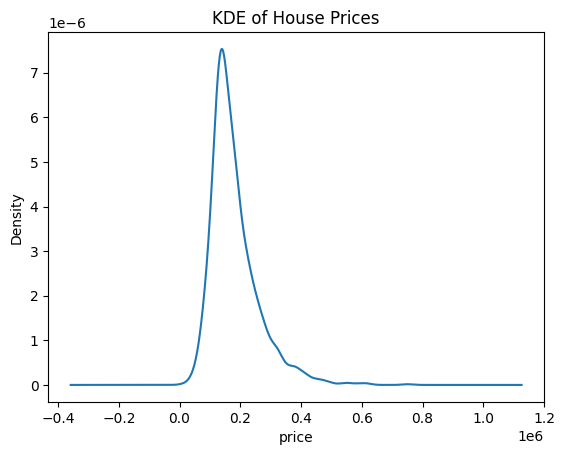

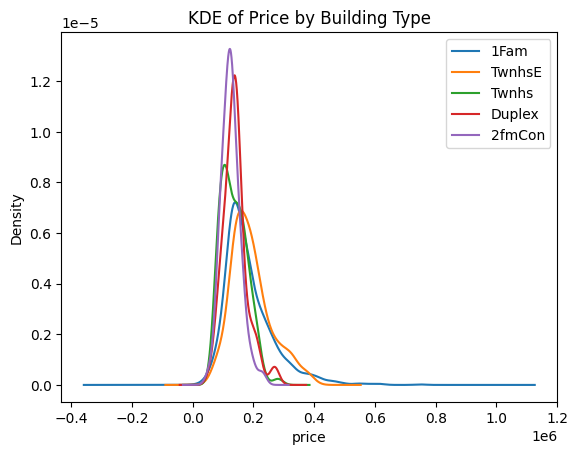

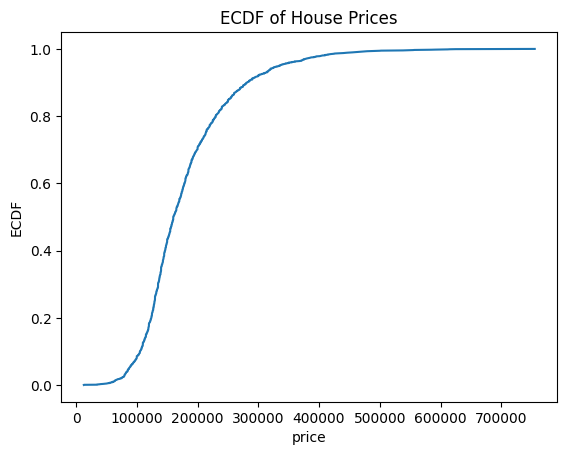

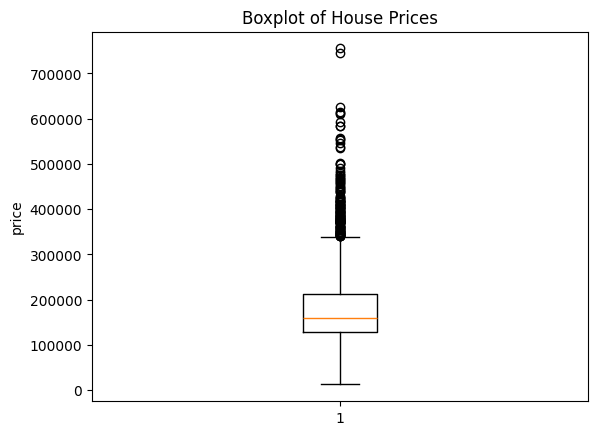

C:\Users\shrey\AppData\Local\Temp\ipykernel_10708\2926419249.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=types, vert=True)


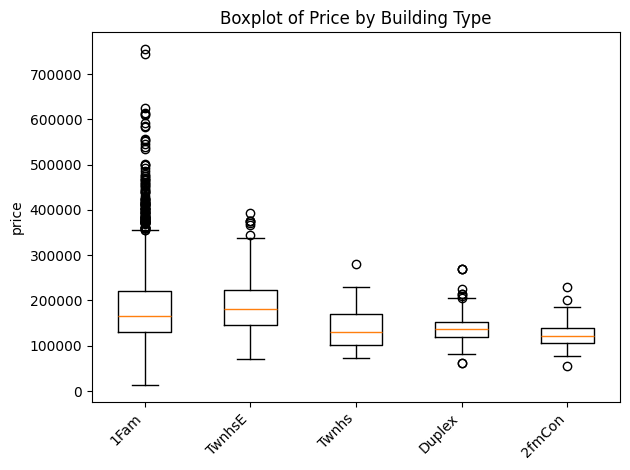

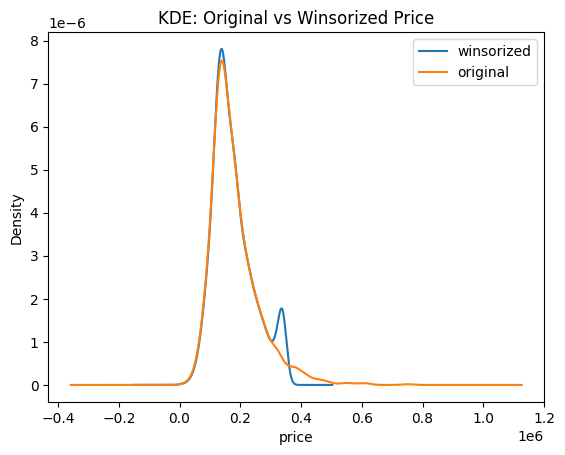

,price,price_winsor
count,2930.000000,2930.000000
mean,180796.060068,177082.283959
std,79886.692357,67906.837135
min,12789.000000,12789.000000
25%,129500.000000,129500.000000
50%,160000.000000,160000.000000
75%,213500.000000,213500.000000
max,755000.000000,339500.000000


In [10]:
#1 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ames_prices.csv")
df.head()
df.columns

#2 
df["price"].plot(kind="kde")
plt.xlabel("price")
plt.title("KDE of House Prices")
plt.show()

df["price"].describe()

for t in df["Bldg.Type"].dropna().unique():
    df.loc[df["Bldg.Type"] == t, "price"].plot(kind="kde", label=t)

plt.legend()
plt.xlabel("price")
plt.title("KDE of Price by Building Type")
plt.show()

by_type = df.groupby("Bldg.Type")["price"].describe()
by_type
by_type["mean"].sort_values(ascending=False)
(df.groupby("Bldg.Type")["price"].std()**2).sort_values(ascending=False)

#3
x = np.sort(df["price"].dropna())
y = np.arange(1, len(x)+1) / len(x)

plt.plot(x, y)
plt.xlabel("price")
plt.ylabel("ECDF")
plt.title("ECDF of House Prices")
plt.show()
five_num = df["price"].quantile([0, 0.25, 0.5, 0.75, 1.0])
five_num

#4
plt.boxplot(df["price"].dropna(), vert=True)
plt.ylabel("price")
plt.title("Boxplot of House Prices")
plt.show()
types = df["Bldg.Type"].dropna().unique()
data = [df.loc[df["Bldg.Type"] == t, "price"].dropna() for t in types]

plt.boxplot(data, labels=types, vert=True)
plt.ylabel("price")
plt.title("Boxplot of Price by Building Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#5
q1 = df["price"].quantile(0.25)
q3 = df["price"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df["is_outlier"] = ((df["price"] < lower) | (df["price"] > upper)).astype(int)

df["is_outlier"].value_counts()
lower, upper

#6
df["price_winsor"] = df["price"].clip(lower=lower, upper=upper)

df["price_winsor"].plot(kind="kde", label="winsorized")
df["price"].plot(kind="kde", label="original")
plt.legend()
plt.xlabel("price")
plt.title("KDE: Original vs Winsorized Price")
plt.show()

df[["price", "price_winsor"]].describe()

